OBSERVED EXPERIMENT
Group A: 654/3270 = 20.00%
Group B: 706/3270 = 21.59%
Observed lift: 1.59 percentage points
Analytical (z-test) p-value: 0.1131

SIMULATED NULL DISTRIBUTION (10,000 reshuffles)
Observed lift we're testing against: 1.59 pp
# of simulations at least as extreme: 1206 / 10000
Empirical p-value (simulation):  0.1206
Analytical p-value (z-test):      0.1131


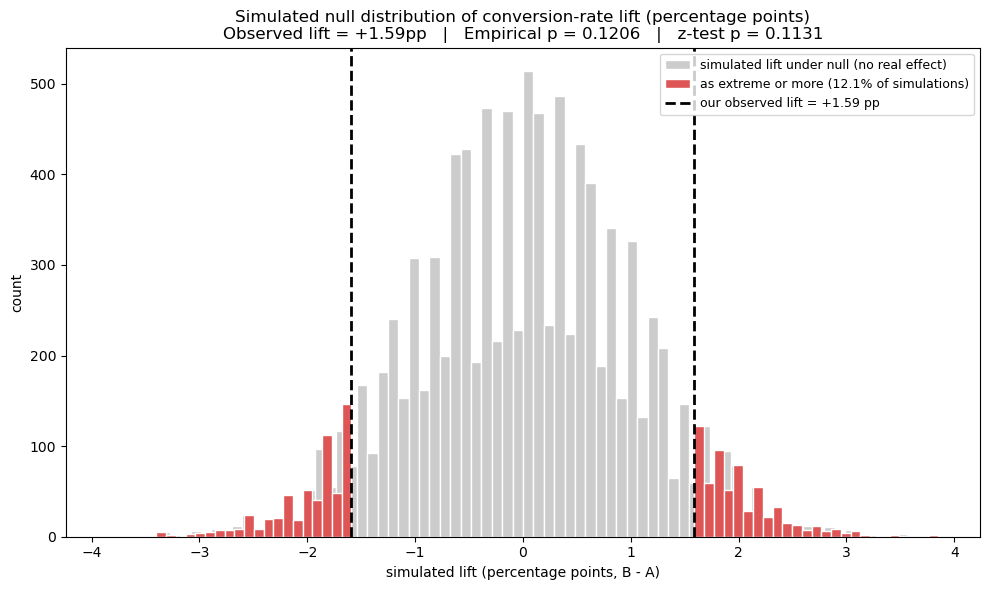

In [3]:
"""
Concrete example: a 1.6 percentage point lift with an 11.3% p-value
---------------------------------------------------------------------
Scenario: conversion rate A/B test.
  Group A (control):   654 / 3270 converted  = 20.00%
  Group B (treatment): 706 / 3270 converted  = 21.59%
  Observed lift: +1.6 percentage points

A standard two-proportion z-test gives p = 0.113 (11.3%).

We now PROVE what that 11.3% means by simulation:
  1. Pool all 6,540 participants' outcomes together (0 = no convert, 1 = convert).
     Under the null hypothesis, the "A" or "B" label carries no information -
     conversion was going to happen or not regardless of label.
  2. Repeatedly (10,000x) randomly reshuffle who is labeled A vs B, and
     recompute the difference in conversion rate each time.
  3. Ask: in what % of these reshuffles is the difference AT LEAST AS BIG
     (in either direction) as our observed 1.6 percentage points?
  4. That % should land right around 11.3%.
"""

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(0)

# ---------------------------------------------------------
# Our engineered observed experiment
# ---------------------------------------------------------
N_PER_GROUP = 3270
CONVERTED_A = 654    # 20.00%
CONVERTED_B = 706    # 21.59%

rate_a = CONVERTED_A / N_PER_GROUP
rate_b = CONVERTED_B / N_PER_GROUP
observed_lift_pp = (rate_b - rate_a) * 100  # in percentage points

# Analytical two-proportion z-test (what a normal A/B testing tool reports)
count = np.array([CONVERTED_B, CONVERTED_A])
nobs = np.array([N_PER_GROUP, N_PER_GROUP])
pooled_p = count.sum() / nobs.sum()
se = np.sqrt(pooled_p * (1 - pooled_p) * (1 / N_PER_GROUP + 1 / N_PER_GROUP))
z_stat = (rate_b - rate_a) / se
p_value_analytical = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("=" * 60)
print("OBSERVED EXPERIMENT")
print("=" * 60)
print(f"Group A: {CONVERTED_A}/{N_PER_GROUP} = {rate_a*100:.2f}%")
print(f"Group B: {CONVERTED_B}/{N_PER_GROUP} = {rate_b*100:.2f}%")
print(f"Observed lift: {observed_lift_pp:.2f} percentage points")
print(f"Analytical (z-test) p-value: {p_value_analytical:.4f}")
print()

# ---------------------------------------------------------
# Build the raw 0/1 outcome data and pool it (this respects the null:
# group label is meaningless, the 1360 "successes" are just spread
# across 6540 people however chance decides)
# ---------------------------------------------------------
group_a = np.array([1] * CONVERTED_A + [0] * (N_PER_GROUP - CONVERTED_A))
group_b = np.array([1] * CONVERTED_B + [0] * (N_PER_GROUP - CONVERTED_B))
pooled = np.concatenate([group_a, group_b])

N_SIMULATIONS = 10_000
simulated_lifts_pp = np.zeros(N_SIMULATIONS)

for i in range(N_SIMULATIONS):
    shuffled = np.random.permutation(pooled)
    sim_a = shuffled[:N_PER_GROUP]
    sim_b = shuffled[N_PER_GROUP:]
    simulated_lifts_pp[i] = (sim_b.mean() - sim_a.mean()) * 100

# ---------------------------------------------------------
# What % of simulations are AT LEAST AS EXTREME as our +1.6pp lift?
# ---------------------------------------------------------
extreme_mask = np.abs(simulated_lifts_pp) >= abs(observed_lift_pp)
empirical_p_value = extreme_mask.mean()

print("=" * 60)
print("SIMULATED NULL DISTRIBUTION (10,000 reshuffles)")
print("=" * 60)
print(f"Observed lift we're testing against: {observed_lift_pp:.2f} pp")
print(f"# of simulations at least as extreme: {extreme_mask.sum()} / {N_SIMULATIONS}")
print(f"Empirical p-value (simulation):  {empirical_p_value:.4f}")
print(f"Analytical p-value (z-test):      {p_value_analytical:.4f}")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(simulated_lifts_pp, bins=80, color="#CCCCCC", edgecolor="white",
        label="simulated lift under null (no real effect)")

tail_right = simulated_lifts_pp[simulated_lifts_pp >= abs(observed_lift_pp)]
tail_left = simulated_lifts_pp[simulated_lifts_pp <= -abs(observed_lift_pp)]
ax.hist(tail_right, bins=25, color="#DD5555", edgecolor="white",
        label=f"as extreme or more ({empirical_p_value:.1%} of simulations)")
ax.hist(tail_left, bins=25, color="#DD5555", edgecolor="white")

ax.axvline(observed_lift_pp, color="black", linestyle="--", linewidth=2,
           label=f"our observed lift = +{observed_lift_pp:.2f} pp")
ax.axvline(-observed_lift_pp, color="black", linestyle="--", linewidth=2)

ax.set_title(
    f"Simulated null distribution of conversion-rate lift (percentage points)\n"
    f"Observed lift = +{observed_lift_pp:.2f}pp   |   "
    f"Empirical p = {empirical_p_value:.4f}   |   z-test p = {p_value_analytical:.4f}"
)
ax.set_xlabel("simulated lift (percentage points, B - A)")
ax.set_ylabel("count")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()

## Conclusion: What Does a P-Value Actually Mean?

Our simulation shows that when there is **truly no real effect** (both
groups drawn from the same underlying process), random sampling noise
alone can still produce an observed lift as large as **+1.59 percentage
points** purely by chance.

By reshuffling the data 10,000 times under the null hypothesis, we found
that a difference *at least this extreme* (in either direction) occurs
in about **12.06%** of simulations — closely matching the **11.31%**
p-value from the standard z-test formula. The two independent methods
agree, confirming what the p-value formula is actually measuring.

**This directly illustrates the meaning of a p-value:**
A p-value is the probability of observing a result *at least this
extreme*, assuming the null hypothesis (no real effect) is true. It is
**not** the probability that the null hypothesis is true, nor the
probability that our result is "wrong."

**On the 0.05 significance threshold:**
Setting alpha = 0.05 means we agree in advance to treat the most extreme
5% of outcomes under the null as "statistically significant." This
implies that *if there is truly no effect*, we should still expect to
see a "significant" result about 5% of the time — a **false positive**,
purely from random noise, not from any real signal in the data.

Importantly, this 5% is a property of the **testing procedure over many
repeated experiments** — not a statement that "there's a 5% chance this
particular result is wrong." Any single result either came from a real
effect or it didn't; the 5% describes how often the *procedure itself*
would be fooled by chance if there were nothing there.

## What a P-Value Means in Real-World A/B Testing

When you run an A/B test — say, testing a new campaign, landing page,
or feature — you observe some uplift (or drop) in your metric. The
question a p-value answers is:

> **"Assuming my change had absolutely no real effect, how likely is
> it that I'd see an uplift this large (or larger) just from random
> noise — seasonality, day-to-day fluctuation, random user variation,
> sampling luck, etc.?"**

### Applying this to a real campaign

Say your campaign shows a **+1.6 percentage point lift**, with a
**p-value of 11.3%**.

This means: *if your campaign genuinely did nothing*, a swing this
size would still happen by chance alone about **1 out of every 9
times** you ran a similar test — just from things like seasonality,
random traffic mix, or normal variance in user behavior, not from the
campaign itself.

Since 11.3% is higher than the usual 5% risk threshold, you don't have
strong enough evidence to say "this uplift is real." It's just as
plausible that your campaign is doing *nothing at all*, and you got
a lucky-looking number.

### Why the 5% cutoff exists

Setting **α = 0.05** means: you're willing to accept that, *if there
is truly no real effect*, you'll still falsely call a result
"significant" about 5% of the time. It's a pre-agreed error rate for
the testing procedure — not a guarantee about any single result.

- p-value **below 5%** → the observed effect would be rare under pure
  chance, so you have reasonable evidence to believe something real
  is happening
- p-value **above 5%** → the observed effect is common enough under
  pure chance (seasonality, noise, natural variance) that you can't
  confidently rule out "this campaign did nothing"

### The key mental model

A p-value is **not** "the probability my campaign has no effect."

A p-value **is** "assuming my campaign has no effect, how surprising
is this data?"

In practice, this means: every uplift you see in an A/B test could be
one of two things —

1. A real effect from your campaign, or
2. Random noise (seasonality, traffic quality, timing, sample luck)
   that would have shown up even if the campaign changed nothing

The p-value tells you how consistent your result is with explanation
#2. A low p-value doesn't *prove* #1 — it just means #2 becomes an
increasingly uncomfortable coincidence to believe.